# Crawl Link

In [1]:
import urllib3
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import pandas as pd

# matikan warning SSL insecure
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def scrape_all_links(base_url, max_pages=50):
    visited = set()
    results = []

    def scrape_page(url):
        try:
            response = requests.get(url, verify=False, timeout=10)
            soup = BeautifulSoup(response.text, 'html.parser')

            # ambil semua link keluar dari halaman ini
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                results.append({
                    "Page": url,
                    "Link Keluar": full_link
                })

            # cari link internal untuk dilanjutkan
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                # ambil link internal (masih di domain utama)
                if full_link.startswith(base_url) and full_link not in visited:
                    visited.add(full_link)
                    if len(visited) < max_pages:
                        scrape_page(full_link)

        except Exception as e:
            print(f"⚠️ Gagal akses {url}: {e}")

    # mulai dari base_url
    visited.add(base_url)
    scrape_page(base_url)

    # rapikan dataframe
    df = pd.DataFrame(results).reset_index(drop=True)
    df.index += 1
    df.insert(0, "No", df.index)
    return df

# contoh penggunaan untuk website Teknik Trunojoyo
url = "https://teknik.trunojoyo.ac.id/"
df_links = scrape_all_links(url, max_pages=30)

# tampilkan semua baris sampai index terakhir
print(df_links.to_string(index=False))



  No                                                                                           Page                                                                                                            Link Keluar
   1                                                                https://teknik.trunojoyo.ac.id/                                                                                        https://teknik.trunojoyo.ac.id/
   2                                                                https://teknik.trunojoyo.ac.id/                                                                   https://teknik.trunojoyo.ac.id/#kingster-mobile-menu
   3                                                                https://teknik.trunojoyo.ac.id/                                                                                        https://teknik.trunojoyo.ac.id/
   4                                                                https://teknik.trunojoyo.ac.id/                         

Jumlah tautan ditemukan: 5514
5 baris pertama:
   No                             Page  \
1   1  https://teknik.trunojoyo.ac.id/   
2   2  https://teknik.trunojoyo.ac.id/   
3   3  https://teknik.trunojoyo.ac.id/   
4   4  https://teknik.trunojoyo.ac.id/   
5   5  https://teknik.trunojoyo.ac.id/   

                                         Link Keluar  
1                    https://teknik.trunojoyo.ac.id/  
2  https://teknik.trunojoyo.ac.id/#kingster-mobil...  
3                    https://teknik.trunojoyo.ac.id/  
4           https://teknik.trunojoyo.ac.id/about-us/  
5            https://teknik.trunojoyo.ac.id/sekilas/   



/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


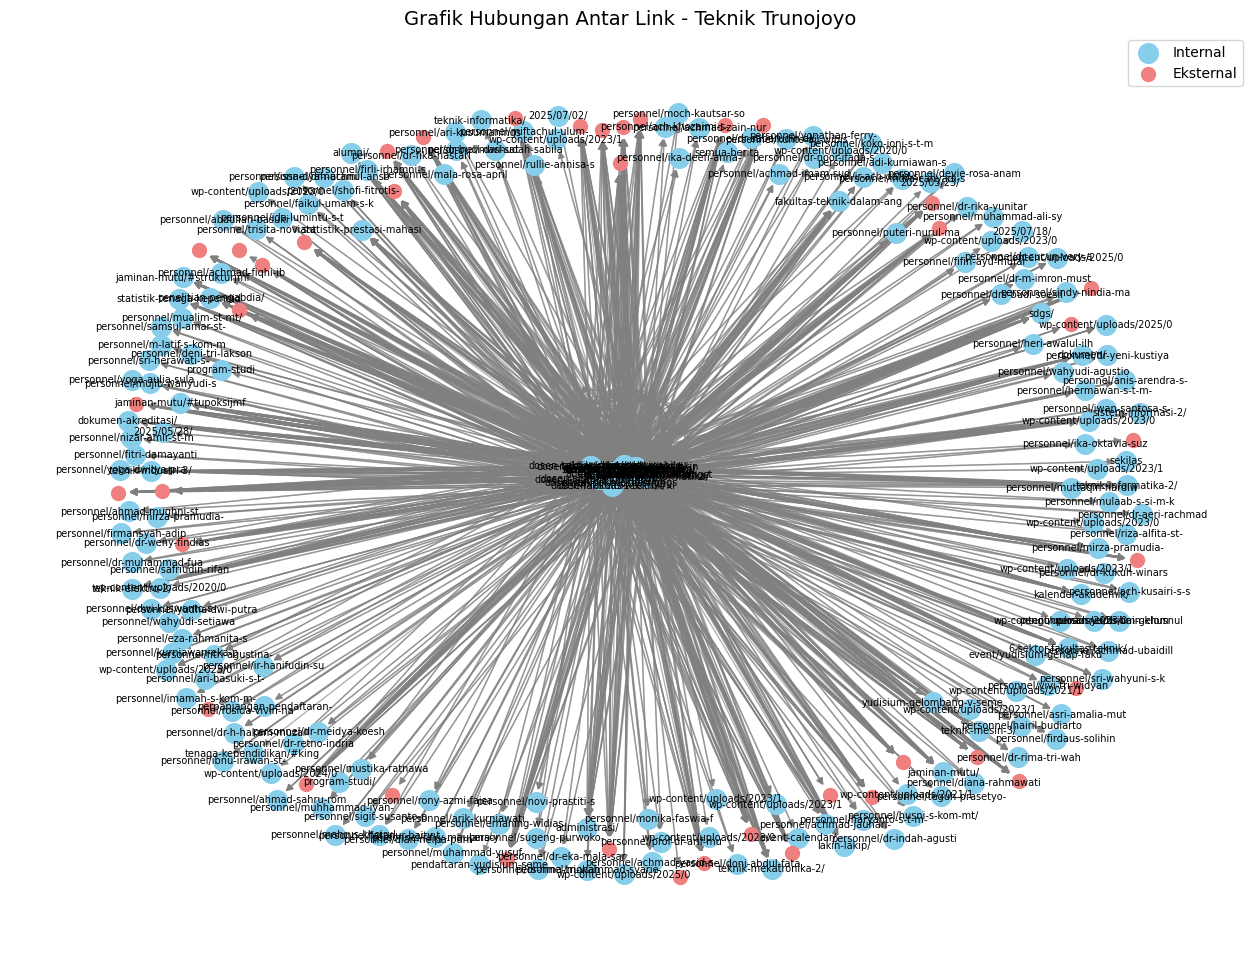

In [2]:
import urllib3
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Matikan warning SSL insecure
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def scrape_all_links(base_url, max_pages=50):
    """
    Mengambil semua tautan dari sebuah situs web hingga batas halaman tertentu.
    """
    visited = set()
    results = []

    def scrape_page(url):
        try:
            response = requests.get(url, verify=False, timeout=10)
            soup = BeautifulSoup(response.text, 'html.parser')

            # Ambil semua link keluar
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                results.append({
                    "Page": url,
                    "Link Keluar": full_link
                })

            # Cari link internal untuk dilanjutkan
            for a in soup.find_all('a', href=True):
                href = a['href'].strip()
                if not href or href == "#":
                    continue
                full_link = urljoin(url, href)
                if full_link.startswith(base_url) and full_link not in visited:
                    visited.add(full_link)
                    if len(visited) < max_pages:
                        scrape_page(full_link)

        except Exception as e:
            print(f"⚠️ Gagal akses {url}: {e}")

    visited.add(base_url)
    scrape_page(base_url)

    df = pd.DataFrame(results).reset_index(drop=True)
    df.index += 1
    df.insert(0, "No", df.index)
    return df


def visualize_graph(df, base_url):
    """
    Membuat visualisasi graf link internal vs eksternal.
    Internal = biru, Eksternal = merah.
    """
    G = nx.DiGraph()

    for _, row in df.iterrows():
        page = row['Page']
        link = row['Link Keluar']
        G.add_edge(page, link)

    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(G, k=0.15, iterations=40)

    # Pisahkan node internal & eksternal
    internal_nodes = [node for node in G.nodes if str(node).startswith(base_url)]
    external_nodes = [node for node in G.nodes if not str(node).startswith(base_url)]

    # Gambar node internal biru
    nx.draw_networkx_nodes(G, pos, nodelist=internal_nodes, node_size=200, node_color='skyblue', label="Internal")
    # Gambar node eksternal merah
    nx.draw_networkx_nodes(G, pos, nodelist=external_nodes, node_size=100, node_color='lightcoral', label="Eksternal")

    # Edge
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrowsize=10, alpha=0.6)

    # Label node internal saja (biar tidak terlalu ramai)
    labels = {node: node.replace(base_url, "")[:25] for node in internal_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=7)

    plt.title("Grafik Hubungan Antar Link - Teknik Trunojoyo", fontsize=14)
    plt.legend(scatterpoints=1)
    plt.axis("off")
    plt.show()


# --- MAIN ---
if __name__ == "__main__":
    url = "https://teknik.trunojoyo.ac.id/"
    max_pages_to_crawl = 30

    df_links = scrape_all_links(url, max_pages=max_pages_to_crawl)

    if not df_links.empty:
        print("Jumlah tautan ditemukan:", len(df_links))
        print("5 baris pertama:")
        print(df_links.head(), "\n")

        visualize_graph(df_links, url)
    else:
        print("⚠️ Tidak ada data tautan ditemukan.")


# Crawl Link

In [3]:
# simpan ke csv (opsional)
df_links.to_csv("semua_link_teknik.csv", index=False, encoding="utf-8-sig")
